# Data Engineering

In [44]:
import json
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
})
with open("data/hotpot_dev_distractor_v1.json") as f:
    full_dev = json.load(f)

print(f"Total questions: {len(full_dev)}")
print(f"Keys: {full_dev[0].keys()}")
print(f"Example question: {full_dev[0]['question']}")
print(f"Example answer: {full_dev[0]['answer']}")
print(f"Type: {full_dev[0]['type']}, Level: {full_dev[0]['level']}")
print(f"Num paragraphs in context: {len(full_dev[0]['context'])}")

Total questions: 7405
Keys: dict_keys(['_id', 'answer', 'question', 'supporting_facts', 'context', 'type', 'level'])
Example question: Were Scott Derrickson and Ed Wood of the same nationality?
Example answer: yes
Type: comparison, Level: hard
Num paragraphs in context: 10


In [2]:
import random

random.seed(42)

bridge = [q for q in full_dev if q["type"] == "bridge"]
comparison = [q for q in full_dev if q["type"] == "comparison"]

print(f"Bridge: {len(bridge)}, Comparison: {len(comparison)}")

# 100 of each type
dev_slice = random.sample(bridge, 100) + random.sample(comparison, 100)
random.shuffle(dev_slice)  # mix types together

print(f"Slice size: {len(dev_slice)}")
print(f"Bridge in slice: {sum(1 for q in dev_slice if q['type'] == 'bridge')}")
print(f"Comparison in slice: {sum(1 for q in dev_slice if q['type'] == 'comparison')}")

Bridge: 5918, Comparison: 1487
Slice size: 200
Bridge in slice: 100
Comparison in slice: 100


In [3]:
# Use this during development
dev_20 = dev_slice[:20]

# Quick look
for q in dev_20[:3]:
    print(f"Q: {q['question']}")
    print(f"A: {q['answer']}")
    print(f"Type: {q['type']}, Level: {q['level']}")
    print(f"Paragraphs: {[p[0] for p in q['context']]}")
    print(f"Supporting facts: {q['supporting_facts']}")
    print("---")

Q: Brett McClure competed in the pommel horse event at the 2001 Goodwill Games in what Australian province?
A: Queensland
Type: bridge, Level: hard
Paragraphs: ['2001 Goodwill Games', 'Brett McClure', 'Masayoshi Yamamoto', 'Louis Smith (gymnast)', 'Luke Stannard', 'Quinto Vadi', 'Ioan Silviu Suciu', 'Alexander Artemev', 'Heikki Savolainen (gymnast)', 'Marius Urzică']
Supporting facts: [['Brett McClure', 0], ['Brett McClure', 1], ['2001 Goodwill Games', 1]]
---
Q: Does Frank Pepe Pizzeria Napoletana or Donatos Pizza have more locations?
A: Donatos
Type: comparison, Level: hard
Paragraphs: ['Antico Pizza', 'Wooster Square', 'Pizza Land', 'Frank Pepe Pizzeria Napoletana', 'Rabbe Grönblom', 'Tutta Bella Neapolitan Pizzeria', 'New Haven-style pizza', "Tony's Pizza Napoletana", 'California-style pizza', 'Donatos Pizza']
Supporting facts: [['Frank Pepe Pizzeria Napoletana', 0], ['Donatos Pizza', 0], ['Donatos Pizza', 1], ['Donatos Pizza', 2]]
---
Q: The organization that Nicolae Titulescu ser

In [4]:
def get_corpus(question_item):
    """
    Returns a list of dicts, one per paragraph.
    Each dict has: title, sentences, full_text
    """
    corpus = []
    for title, sentences in question_item["context"]:
        corpus.append({
            "title": title,
            "sentences": sentences,
            "full_text": " ".join(sentences)
        })
    return corpus

def get_gold_titles(question_item):
    """Returns the titles of the two gold supporting paragraphs."""
    return list(set(fact[0] for fact in question_item["supporting_facts"]))

# Quick sanity check
sample = dev_20[0]
corpus = get_corpus(sample)
gold = get_gold_titles(sample)

print(f"Question: {sample['question']}")
print(f"Answer: {sample['answer']}")
print(f"Gold paragraphs: {gold}")
print(f"All paragraph titles: {[p['title'] for p in corpus]}")

Question: Brett McClure competed in the pommel horse event at the 2001 Goodwill Games in what Australian province?
Answer: Queensland
Gold paragraphs: ['2001 Goodwill Games', 'Brett McClure']
All paragraph titles: ['2001 Goodwill Games', 'Brett McClure', 'Masayoshi Yamamoto', 'Louis Smith (gymnast)', 'Luke Stannard', 'Quinto Vadi', 'Ioan Silviu Suciu', 'Alexander Artemev', 'Heikki Savolainen (gymnast)', 'Marius Urzică']


In [5]:
import re
from collections import Counter

def normalize(text):
    """Lowercase, remove articles and punctuation."""
    text = text.lower()
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    text = re.sub(r"[^a-z0-9 ]", "", text)
    return " ".join(text.split())

def exact_match(pred, gold):
    return int(normalize(pred) == normalize(gold))

def f1_score(pred, gold):
    pred_tokens = normalize(pred).split()
    gold_tokens = normalize(gold).split()
    common = Counter(pred_token for pred_token in pred_tokens 
                     if pred_token in gold_tokens)
    if not common:
        return 0.0
    precision = sum(common.values()) / len(pred_tokens)
    recall = sum(common.values()) / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

def evaluate(results):
    """
    results: list of dicts with keys:
        question, gold_answer, pred_answer, type, level
    Returns aggregate and per-type metrics.
    """
    rows = []
    for r in results:
        em = exact_match(r["pred_answer"], r["gold_answer"])
        f1 = f1_score(r["pred_answer"], r["gold_answer"])
        rows.append({**r, "em": em, "f1": f1})

    def agg(subset):
        if not subset:
            return {"em": 0, "f1": 0, "n": 0}
        return {
            "em": sum(r["em"] for r in subset) / len(subset),
            "f1": sum(r["f1"] for r in subset) / len(subset),
            "n": len(subset)
        }

    bridge_rows = [r for r in rows if r["type"] == "bridge"]
    comparison_rows = [r for r in rows if r["type"] == "comparison"]

    print("=== Overall ===")
    print(agg(rows))
    print("=== Bridge ===")
    print(agg(bridge_rows))
    print("=== Comparison ===")
    print(agg(comparison_rows))

    return rows  # return full rows for per-question inspection

# Test the harness with dummy predictions
dummy_results = [
    {"question": q["question"], "gold_answer": q["answer"],
     "pred_answer": "dummy", "type": q["type"], "level": q["level"]}
    for q in dev_20
]
rows = evaluate(dummy_results)

=== Overall ===
{'em': 0.0, 'f1': 0.0, 'n': 20}
=== Bridge ===
{'em': 0.0, 'f1': 0.0, 'n': 15}
=== Comparison ===
{'em': 0.0, 'f1': 0.0, 'n': 5}


# RAG Implementation

In [6]:
import requests
import json as json_lib

OLLAMA_URL = "http://localhost:11434/api/generate"
# MODEL = "qwen2.5:7b-instruct"
# MODEL = "llama3.1:8b-instruct-q4_K_M"
MODEL = "gemma2:9b"

def llm(prompt, system=None, format_json=False, temperature=0.0):
    """Call local Ollama. Returns text string."""
    payload = {
        "model": MODEL,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": temperature}
    }
    if system:
        payload["system"] = system
    if format_json:
        payload["format"] = "json"
    
    r = requests.post(OLLAMA_URL, json=payload, timeout=120)
    r.raise_for_status()
    return r.json()["response"].strip()

# Sanity check — should answer "Paris"
print(llm("What is the capital of France? Answer in one word."))

Paris


In [7]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Embedding model + chunking
embedder = SentenceTransformer("BAAI/bge-small-en-v1.5")

def embed(texts):
    """Batch embed a list of strings. Returns (n, d) numpy array."""
    return embedder.encode(texts, normalize_embeddings=True, show_progress_bar=False)

# Quick test
vecs = embed(["hello world", "goodbye world"])
print(f"Shape: {vecs.shape}")  # (2, 384)

Shape: (2, 384)


/home/hieu/anaconda3/envs/project1/lib/python3.9/site-packages/torch/nn/modules/module.py:1562: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [8]:
# Vanilla RAG retriever
def vanilla_retrieve(question, corpus, top_k=3):
    """
    corpus: list of dicts from get_corpus()
    Returns top_k paragraphs ranked by cosine similarity to question.
    """
    texts = [f"{p['title']}. {p['full_text']}" for p in corpus]
    doc_vecs = embed(texts)
    q_vec = embed([question])[0]
    
    scores = doc_vecs @ q_vec  # cosine sim (already normalized)
    top_indices = np.argsort(-scores)[:top_k]
    
    return [corpus[i] for i in top_indices]

# Test on one question
sample = dev_20[0]
corpus = get_corpus(sample)
gold = get_gold_titles(sample)
retrieved = vanilla_retrieve(sample["question"], corpus, top_k=3)

print(f"Q: {sample['question']}")
print(f"Gold: {gold}")
print(f"Retrieved: {[p['title'] for p in retrieved]}")
print(f"Recall: {len(set(p['title'] for p in retrieved) & set(gold)) / len(gold):.2f}")

Q: Brett McClure competed in the pommel horse event at the 2001 Goodwill Games in what Australian province?
Gold: ['2001 Goodwill Games', 'Brett McClure']
Retrieved: ['Brett McClure', '2001 Goodwill Games', 'Masayoshi Yamamoto']
Recall: 1.00


In [9]:
# Prompt
GEN_SYSTEM = """You are a careful question-answering assistant. Answer the question using ONLY the provided context. 
Give a short, direct answer — typically a single entity, date, or short phrase. 
Do not explain. Do not repeat the question. If the context does not contain the answer, respond with "unknown"."""

def format_context(paragraphs):
    """Format retrieved paragraphs for the prompt."""
    return "\n\n".join(
        f"[{p['title']}]\n{p['full_text']}" for p in paragraphs
    )

def generate_answer(question, paragraphs):
    context = format_context(paragraphs)
    prompt = f"""Context:
{context}

Question: {question}

Answer:"""
    return llm(prompt, system=GEN_SYSTEM, temperature=0.0)

# Test
pred = generate_answer(sample["question"], retrieved)
print(f"Q: {sample['question']}")
print(f"Gold: {sample['answer']}")
print(f"Pred: {pred}")

Q: Brett McClure competed in the pommel horse event at the 2001 Goodwill Games in what Australian province?
Gold: Queensland
Pred: Queensland


In [10]:
from tqdm import tqdm

def run_vanilla_rag(questions, top_k=3):
    results = []
    for q in tqdm(questions):
        corpus = get_corpus(q)
        retrieved = vanilla_retrieve(q["question"], corpus, top_k=top_k)
        pred = generate_answer(q["question"], retrieved)
        results.append({
            "question": q["question"],
            "gold_answer": q["answer"],
            "pred_answer": pred,
            "type": q["type"],
            "level": q["level"],
            "retrieved_paragraphs": retrieved,  # full paragraph dicts
            "retrieved_titles": [p["title"] for p in retrieved],
            "gold_titles": get_gold_titles(q),
        })
    return results

vanilla_results_20 = run_vanilla_rag(dev_20)
vanilla_rows_20 = evaluate(vanilla_results_20)

100%|███████████████████████████████████████████████████████████████████████████████████| 20/20 [00:05<00:00,  3.90it/s]

=== Overall ===
{'em': 0.55, 'f1': 0.6524242424242425, 'n': 20}
=== Bridge ===
{'em': 0.6, 'f1': 0.7098989898989899, 'n': 15}
=== Comparison ===
{'em': 0.4, 'f1': 0.48, 'n': 5}


In [11]:
# Inspect failure
# Where did vanilla RAG fail? If we know, we know!
failures = [r for r in vanilla_rows_20 if r["f1"] < 0.5]
print(f"Failures: {len(failures)}/{len(vanilla_rows_20)}\n")
print("=" * 80)

for i, f in enumerate(failures):
    context = format_context(f["retrieved_paragraphs"])
    full_prompt = f"""Context:
{context}

Question: {f['question']}

Answer:"""
    
    print(f"\n### FAILURE {i+1}/{len(failures)} ###")
    print(f"Type: {f['type']} | Level: {f['level']}")
    print(f"Gold: {f['gold_answer']}")
    print(f"Pred: {f['pred_answer']}")
    print(f"Gold titles: {f['gold_titles']}")
    print(f"Retrieved titles: {f['retrieved_titles']}")
    retrieval_hit = set(f['retrieved_titles']) & set(f['gold_titles'])
    print(f"Gold retrieved: {len(retrieval_hit)}/{len(f['gold_titles'])}")
    print(f"\n--- SYSTEM ---")
    print(GEN_SYSTEM)
    print(f"\n--- PROMPT ---")
    print(full_prompt)
    print("=" * 80)

Failures: 7/20


### FAILURE 1/7 ###
Type: comparison | Level: hard
Gold: Donatos
Pred: unknown
Gold titles: ['Donatos Pizza', 'Frank Pepe Pizzeria Napoletana']
Retrieved titles: ['Frank Pepe Pizzeria Napoletana', 'Donatos Pizza', "Tony's Pizza Napoletana"]
Gold retrieved: 2/2

--- SYSTEM ---
You are a careful question-answering assistant. Answer the question using ONLY the provided context. 
Give a short, direct answer — typically a single entity, date, or short phrase. 
Do not explain. Do not repeat the question. If the context does not contain the answer, respond with "unknown".

--- PROMPT ---
Context:
[Frank Pepe Pizzeria Napoletana]
Frank Pepe Pizzeria Napoletana, known locally as Pepe's, is a popular pizza restaurant in the Wooster Square neighborhood of New Haven, Connecticut, at 163 Wooster Street.  Opened in 1925, it is one of the oldest and best known pizzerias in the United States.

[Donatos Pizza]
Donatos Pizza is a pizza delivery restaurant chain headquartered in Columbus

# One-shot GraphRAG

In [12]:
# Entity extraction
import spacy

nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    """Returns a set of entity strings found in text."""
    doc = nlp(text)
    # Keep common HotpotQA entity types
    keep = {"PERSON", "ORG", "GPE", "LOC", "WORK_OF_ART", "EVENT", "FAC", "NORP", "PRODUCT"}
    entities = set()
    for ent in doc.ents:
        if ent.label_ in keep:
            # Normalize: strip, lowercase for matching
            entities.add(ent.text.strip())
    return entities

# Test on one paragraph
sample = dev_20[0]
corpus = get_corpus(sample)
print(f"Paragraph 1 title: {corpus[0]['title']}")
print(f"Paragraph 1 text: {corpus[0]['full_text'][:200]}...")
print(f"Entities: {extract_entities(corpus[0]['full_text'])}")
print()
print(f"Question: {sample['question']}")
print(f"Question entities: {extract_entities(sample['question'])}")

/home/hieu/anaconda3/envs/project1/lib/python3.9/site-packages/spacy/util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


Paragraph 1 title: 2001 Goodwill Games
Paragraph 1 text: The 2001 Goodwill Games was the fifth and final edition of the international multi-sport event.  The competition was held in Brisbane, Queensland, Australia from 29 August to 9 September 2001.  A tota...
Entities: {'Australia', 'Queensland', 'Goodwill Games', 'Brisbane'}

Question: Brett McClure competed in the pommel horse event at the 2001 Goodwill Games in what Australian province?
Question entities: {'Australian', 'Goodwill Games', 'Brett McClure'}


In [13]:
# Build the graph
import networkx as nx

def build_graph(corpus):
    """
    Build an entity co-occurrence graph from a per-question corpus.
    Nodes: entities (strings).
    Edges: (e1, e2) if both entities appear in the same paragraph.
    Node attribute 'paragraphs': set of paragraph titles the entity appears in.
    """
    G = nx.Graph()
    
    for para in corpus:
        # Force paragraph title as an entity + spaCy extractions
        entities = extract_entities(para["full_text"])
        entities.add(para["title"])  # title is always a node
        
        # Add nodes, track which paragraphs each entity appears in
        for e in entities:
            if e not in G:
                G.add_node(e, paragraphs=set())
            G.nodes[e]["paragraphs"].add(para["title"])
        
        # Add co-occurrence edges between all pairs in this paragraph
        entities = list(entities)
        for i in range(len(entities)):
            for j in range(i + 1, len(entities)):
                G.add_edge(entities[i], entities[j])
    
    return G

# Test on one question
sample = dev_20[0]
corpus = get_corpus(sample)
G = build_graph(corpus)

print(f"Question: {sample['question']}")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"\nSample nodes with their paragraphs:")
for node in list(G.nodes())[:10]:
    print(f"  {node} → {G.nodes[node]['paragraphs']}")

Question: Brett McClure competed in the pommel horse event at the 2001 Goodwill Games in what Australian province?
Nodes: 83
Edges: 516

Sample nodes with their paragraphs:
  2001 Goodwill Games → {'2001 Goodwill Games'}
  Brisbane → {'2001 Goodwill Games', 'Brett McClure'}
  Queensland → {'2001 Goodwill Games'}
  Australia → {'2001 Goodwill Games', 'Brett McClure'}
  Goodwill Games → {'2001 Goodwill Games', 'Brett McClure'}
  Washington → {'Brett McClure'}
  McClure → {'Brett McClure'}
  American → {'Alexander Artemev', 'Luke Stannard', 'Brett McClure'}
  Yakima → {'Brett McClure'}
  the 2004 Summer Olympics → {'Brett McClure'}


In [14]:
# Graph-based retrieval
def graph_retrieve(question, corpus, G, top_k=3, hops=1, alpha=0.5):
    """
    1. Extract entities from the question.
    2. Match question entities to graph nodes (with fuzzy fallback).
    3. Expand to `hops`-hop neighbors in the graph.
    4. Collect paragraphs those entities appear in.
    5. Rank paragraphs by how many seed-or-neighbor entities they contain.
    6. Return top_k paragraphs.
    """
    # Step 1: extract question entities
    q_entities = extract_entities(question)
    
    graph_nodes = set(G.nodes())
    # Seed matching
    seeds = set()
    for qe in q_entities:
        if qe in graph_nodes:
            seeds.add(qe)
        else:
            qe_lower = qe.lower()
            for node in graph_nodes:
                if qe_lower in node.lower() or node.lower() in qe_lower:
                    seeds.add(node)
    
    # Expand
    expanded = set(seeds)
    frontier = set(seeds)
    for _ in range(hops):
        next_frontier = set()
        for node in frontier:
            next_frontier.update(G.neighbors(node))
        expanded.update(next_frontier)
        frontier = next_frontier
    
    # Graph score (same as before)
    title_to_para = {p["title"]: p for p in corpus}
    para_entity_count = {}
    for node in G.nodes():
        for para_title in G.nodes[node]["paragraphs"]:
            para_entity_count[para_title] = para_entity_count.get(para_title, 0) + 1
    
    graph_scores = {}
    for para_title in title_to_para:
        s = 0.0
        if para_title in seeds:
            s += 10.0
        elif any(G.has_edge(para_title, seed) for seed in seeds 
                 if para_title in G and seed in G):
            s += 3.0
        
        matched = sum(1 for node in expanded 
                      if node in G.nodes and para_title in G.nodes[node]["paragraphs"])
        s += matched / para_entity_count.get(para_title, 1)
        graph_scores[para_title] = s
    
    # Semantic score (same as vanilla RAG)
    texts = [f"{p['title']}. {p['full_text']}" for p in corpus]
    doc_vecs = embed(texts)
    q_vec = embed([question])[0]
    sem_scores = {corpus[i]["title"]: float(doc_vecs[i] @ q_vec) 
                  for i in range(len(corpus))}
    
    # Normalize both to [0, 1] and combine
    def normalize(d):
        vals = list(d.values())
        if not vals or max(vals) == min(vals):
            return {k: 0.0 for k in d}
        lo, hi = min(vals), max(vals)
        return {k: (v - lo) / (hi - lo) for k, v in d.items()}
    
    g_norm = normalize(graph_scores)
    s_norm = normalize(sem_scores)
    
    combined = {t: alpha * g_norm.get(t, 0) + (1 - alpha) * s_norm.get(t, 0)
                for t in title_to_para}
    
    ranked = sorted(combined.items(), key=lambda x: -x[1])
    top_titles = [t for t, _ in ranked[:top_k]]
    retrieved = [title_to_para[t] for t in top_titles]
    
    return retrieved, seeds, expanded

# Test on the same question
retrieved, seeds, expanded = graph_retrieve(
    sample["question"], corpus, G, top_k=3, hops=1
)

print(f"Question: {sample['question']}")
print(f"Question entities → seeds: {seeds}")
print(f"Expanded neighborhood size: {len(expanded)}")
print(f"Retrieved titles: {[p['title'] for p in retrieved]}")
print(f"Gold titles: {get_gold_titles(sample)}")

Question: Brett McClure competed in the pommel horse event at the 2001 Goodwill Games in what Australian province?
Question entities → seeds: {'Brett McClure', 'Australia', 'Goodwill Games'}
Expanded neighborhood size: 16
Retrieved titles: ['Brett McClure', '2001 Goodwill Games', 'Masayoshi Yamamoto']
Gold titles: ['2001 Goodwill Games', 'Brett McClure']


/home/hieu/anaconda3/envs/project1/lib/python3.9/site-packages/torch/nn/modules/module.py:1562: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [15]:
def run_oneshot_graphrag(questions, top_k=3, hops=1):
    results = []
    for q in tqdm(questions):
        corpus = get_corpus(q)
        G = build_graph(corpus)
        retrieved, seeds, expanded = graph_retrieve(
            q["question"], corpus, G, top_k=top_k, hops=hops
        )
        
        # Fallback: if graph retrieval returns nothing (no seed match),
        # fall back to vanilla retrieval so we don't feed empty context.
        if not retrieved:
            retrieved = vanilla_retrieve(q["question"], corpus, top_k=top_k)
        
        pred = generate_answer(q["question"], retrieved)
        
        results.append({
            "question": q["question"],
            "gold_answer": q["answer"],
            "pred_answer": pred,
            "type": q["type"],
            "level": q["level"],
            "retrieved_paragraphs": retrieved,
            "retrieved_titles": [p["title"] for p in retrieved],
            "gold_titles": get_gold_titles(q),
            "num_seeds": len(seeds),
            "num_expanded": len(expanded),
        })
    return results

oneshot_results_20 = run_oneshot_graphrag(dev_20)
oneshot_rows_20 = evaluate(oneshot_results_20)

100%|███████████████████████████████████████████████████████████████████████████████████| 20/20 [00:08<00:00,  2.35it/s]

=== Overall ===
{'em': 0.4, 'f1': 0.5607575757575758, 'n': 20}
=== Bridge ===
{'em': 0.4, 'f1': 0.5432323232323232, 'n': 15}
=== Comparison ===
{'em': 0.4, 'f1': 0.6133333333333333, 'n': 5}


In [16]:
# comparison with vanilla RAG
print("=" * 70)
print(f"{'Question':<50} {'Vanilla':<12} {'OneShot':<12}")
print("=" * 70)

# Match results by question
vanilla_by_q = {r["question"]: r for r in vanilla_rows_20}
oneshot_by_q = {r["question"]: r for r in oneshot_rows_20}

improved = 0
hurt = 0
same = 0
for q_text in vanilla_by_q:
    v = vanilla_by_q[q_text]
    o = oneshot_by_q[q_text]
    v_f1 = v["f1"]
    o_f1 = o["f1"]
    
    marker = ""
    if o_f1 > v_f1 + 0.1:
        marker = "↑"
        improved += 1
    elif o_f1 < v_f1 - 0.1:
        marker = "↓"
        hurt += 1
    else:
        same += 1
    
    print(f"{q_text[:48]:<50} F1={v_f1:.2f}      F1={o_f1:.2f} {marker}")

print("=" * 70)
print(f"Improved by graph: {improved}")
print(f"Hurt by graph:     {hurt}")
print(f"Roughly equal:     {same}")

Question                                           Vanilla      OneShot     
Brett McClure competed in the pommel horse event   F1=1.00      F1=1.00 
Does Frank Pepe Pizzeria Napoletana or Donatos P   F1=0.00      F1=0.67 ↑
The organization that Nicolae Titulescu served t   F1=1.00      F1=0.00 ↓
In what year did a movie that starred both Nicho   F1=1.00      F1=1.00 
In addition to the best known comic servant from   F1=1.00      F1=1.00 
What was the Volvo S70 essentially modeled after   F1=0.80      F1=0.80 
The Disney version of Ebenezer Scrooge was voice   F1=0.00      F1=0.00 
Robin R. Bottin is known for his collaboration w   F1=1.00      F1=1.00 
Bandit was built in 1988 by which Japanese amuse   F1=0.67      F1=0.67 
Which US Supreme court case involved a waiver of   F1=1.00      F1=1.00 
Are Leopold Lummerstorfer and Valeria Sarmiento    F1=0.00      F1=0.00 
What is a luxury goods company long Northern Bou   F1=0.00      F1=0.00 
Erving Goffman was cited as higher than a lit

In [17]:
# Retrieval Recall comparison
def recall(retrieved_titles, gold_titles):
    if not gold_titles:
        return 1.0
    hits = set(retrieved_titles) & set(gold_titles)
    return len(hits) / len(gold_titles)

vanilla_recall = sum(recall(r["retrieved_titles"], r["gold_titles"]) 
                     for r in vanilla_results_20) / len(vanilla_results_20)
oneshot_recall = sum(recall(r["retrieved_titles"], r["gold_titles"]) 
                     for r in oneshot_results_20) / len(oneshot_results_20)

print(f"Retrieval recall @ top-3 on dev_20:")
print(f"  Vanilla RAG:       {vanilla_recall:.3f}")
print(f"  One-shot GraphRAG: {oneshot_recall:.3f}")

Retrieval recall @ top-3 on dev_20:
  Vanilla RAG:       0.900
  One-shot GraphRAG: 0.850


# Running Vanilla and One-shot on 200 questions

In [18]:
print("Running vanilla RAG on dev_200...")
vanilla_results_200 = run_vanilla_rag(dev_slice)

print("\nRunning one-shot GraphRAG on dev_200...")
oneshot_results_200 = run_oneshot_graphrag(dev_slice)

print("\n=== Vanilla RAG ===")
vanilla_rows_200 = evaluate(vanilla_results_200)

print("\n=== One-shot GraphRAG ===")
oneshot_rows_200 = evaluate(oneshot_results_200)

# Recall comparison
v_recall = sum(recall(r["retrieved_titles"], r["gold_titles"]) 
               for r in vanilla_results_200) / len(vanilla_results_200)
o_recall = sum(recall(r["retrieved_titles"], r["gold_titles"]) 
               for r in oneshot_results_200) / len(oneshot_results_200)

print(f"\nRecall @ top-3:")
print(f"  Vanilla:  {v_recall:.3f}")
print(f"  OneShot:  {o_recall:.3f}")

Running vanilla RAG on dev_200...


100%|█████████████████████████████████████████████████████████████████████████████████| 200/200 [01:06<00:00,  3.03it/s]



Running one-shot GraphRAG on dev_200...


100%|█████████████████████████████████████████████████████████████████████████████████| 200/200 [01:24<00:00,  2.36it/s]


=== Vanilla RAG ===
=== Overall ===
{'em': 0.53, 'f1': 0.6690288600288602, 'n': 200}
=== Bridge ===
{'em': 0.5, 'f1': 0.6502005772005771, 'n': 100}
=== Comparison ===
{'em': 0.56, 'f1': 0.6878571428571427, 'n': 100}

=== One-shot GraphRAG ===
=== Overall ===
{'em': 0.485, 'f1': 0.6278621933621933, 'n': 200}
=== Bridge ===
{'em': 0.44, 'f1': 0.5945339105339104, 'n': 100}
=== Comparison ===
{'em': 0.53, 'f1': 0.6611904761904761, 'n': 100}

Recall @ top-3:
  Vanilla:  0.910
  OneShot:  0.910


# Proposed Framework: Self-Refining GraphRAG

In [19]:
# prompt for verifier LLM
VERIFIER_SYSTEM = """You are an evidence verifier. Given a question, a candidate answer, and the supporting context, decide whether the answer is fully supported by the context.

Respond with a JSON object with these fields:
- "status": "supported", "partial", or "unsupported"
    - "supported": the context clearly justifies the answer
    - "partial": some of the answer is justified but key facts are missing
    - "unsupported": the context does not justify the answer
- "weak_entities": list of entities (people, places, organizations, works, dates) that should be in the context but are missing or underdescribed. Include entities NAMED IN THE QUESTION and entities IMPLIED BY THE QUESTION (e.g., if the question asks "voiced by whom", the voice actor is a missing entity type). Use specific names when possible, else descriptive noun phrases (e.g., "Disney's Scrooge voice actor").
- "missing_info": a short phrase (under 15 words) describing what kind of information is missing. Be specific about the fact type sought.

Output only the JSON object."""

def verify_answer(question, paragraphs, answer):
    """
    Returns a dict with keys: status, weak_entities, missing_info.
    Falls back to 'unsupported' on parse failure so the loop continues.
    """
    context = format_context(paragraphs)
    prompt = f"""Question: {question}

Context:
{context}

Candidate answer: {answer}

Evaluate the candidate answer against the context. Output JSON only."""
    
    raw = llm(prompt, system=VERIFIER_SYSTEM, format_json=True, temperature=0.0)
    
    # Parse JSON with fallback
    try:
        result = json.loads(raw)
        # Sanity-check fields
        status = result.get("status", "unsupported")
        if status not in {"supported", "partial", "unsupported"}:
            status = "unsupported"
        weak_entities = result.get("weak_entities", [])
        if not isinstance(weak_entities, list):
            weak_entities = []
        missing_info = result.get("missing_info", "")
        if not isinstance(missing_info, str):
            missing_info = ""
        return {
            "status": status,
            "weak_entities": weak_entities,
            "missing_info": missing_info,
            "raw": raw,
        }
    except (json.JSONDecodeError, AttributeError) as e:
        return {
            "status": "unsupported",
            "weak_entities": [],
            "missing_info": "",
            "raw": raw,
            "parse_error": str(e),
        }

In [20]:
def revise_and_retrieve(question, corpus, G, current_paragraphs, 
                        weak_entities, missing_info, seeds, top_k_new=2):
    """
    Revision with three sources of graph expansion:
    1. Entities from weak_entities (verifier-flagged).
    2. Entities present in currently-retrieved paragraphs (follow-the-links).
    3. Semantic retrieval using missing_info.
    """
    current_titles = {p["title"] for p in current_paragraphs}
    graph_nodes = set(G.nodes())
    title_to_para = {p["title"]: p for p in corpus}
    
    # --- Collect graph expansion seeds ---
    revision_seeds = set()
    
    # (a) From weak_entities
    for we in weak_entities:
        if we in graph_nodes:
            revision_seeds.add(we)
        else:
            we_lower = we.lower()
            for node in graph_nodes:
                if we_lower in node.lower() or node.lower() in we_lower:
                    revision_seeds.add(node)
    
    # (b) From entities in already-retrieved paragraphs (the key addition)
    for node in graph_nodes:
        if any(t in current_titles for t in G.nodes[node]["paragraphs"]):
            revision_seeds.add(node)
    
    # Expand 1 hop
    expanded = set(revision_seeds)
    for node in revision_seeds:
        if node in G:
            expanded.update(G.neighbors(node))
    
    # Candidate paragraphs in expanded set, excluding already-retrieved
    graph_candidates = set()
    for node in expanded:
        if node in G.nodes:
            for para_title in G.nodes[node]["paragraphs"]:
                if para_title not in current_titles and para_title in title_to_para:
                    graph_candidates.add(para_title)
    
    # --- Semantic retrieval using missing_info ---
    semantic_query = f"{question} {missing_info}".strip()
    unretrieved_titles = [t for t in title_to_para if t not in current_titles]
    if unretrieved_titles:
        unretrieved_texts = [f"{title_to_para[t]['title']}. {title_to_para[t]['full_text']}" 
                             for t in unretrieved_titles]
        doc_vecs = embed(unretrieved_texts)
        q_vec = embed([semantic_query])[0]
        sem_scores = {unretrieved_titles[i]: float(doc_vecs[i] @ q_vec) 
                      for i in range(len(unretrieved_titles))}
    else:
        sem_scores = {}
    
    # Combine
    all_candidates = graph_candidates | set(sem_scores.keys())
    if not all_candidates:
        return [], {"num_candidates": 0, "added": []}
    
    # Graph score: boost paragraphs whose titles are direct neighbors 
    # of any current-retrieval entity
    current_paragraph_entities = set()
    for node in graph_nodes:
        if any(t in current_titles for t in G.nodes[node]["paragraphs"]):
            current_paragraph_entities.add(node)
    
    graph_scores = {}
    for t in all_candidates:
        s = 0.0
        # Paragraph title is itself a node connected to current-retrieval entities
        if t in G.nodes:
            for ce in current_paragraph_entities:
                if ce in G.nodes and G.has_edge(t, ce):
                    s += 1.0
                    break
        # Also in graph_candidates from weak_entities expansion
        if t in graph_candidates:
            s += 0.5
        graph_scores[t] = s
    
    def normalize(d):
        vals = list(d.values())
        if not vals or max(vals) == min(vals):
            return {k: 0.0 for k in d}
        lo, hi = min(vals), max(vals)
        return {k: (v - lo) / (hi - lo) for k, v in d.items()}
    
    g_norm = normalize(graph_scores)
    s_norm = normalize({t: sem_scores.get(t, 0.0) for t in all_candidates})
    combined = {t: 0.5 * g_norm[t] + 0.5 * s_norm[t] for t in all_candidates}
    
    ranked = sorted(combined.items(), key=lambda x: -x[1])
    top_new_titles = [t for t, _ in ranked[:top_k_new]]
    new_paragraphs = [title_to_para[t] for t in top_new_titles]
    
    return new_paragraphs, {
        "num_graph_candidates": len(graph_candidates),
        "num_semantic_candidates": len(sem_scores),
        "num_total_candidates": len(all_candidates),
        "added": top_new_titles,
        "ranked_top5": ranked[:5],
    }


# Self-Refining GraphRAG pipeline

In [21]:
def run_self_refining_graphrag(questions, top_k=3, hops=1, max_rounds=2, 
                                top_k_new_per_round=2, verbose=False):
    """
    Full Self-Refining GraphRAG pipeline.
    
    Per question:
      Round 0: initial graph retrieval + generation
      Rounds 1..max_rounds: verify, revise (append new paragraphs), regenerate
      Stop early if verifier says 'supported' or no new candidates found.
    """
    results = []
    for q in tqdm(questions):
        corpus = get_corpus(q)
        G = build_graph(corpus)
        
        # Round 0
        retrieved, seeds, _ = graph_retrieve(
            q["question"], corpus, G, top_k=top_k, hops=hops
        )
        if not retrieved:
            retrieved = vanilla_retrieve(q["question"], corpus, top_k=top_k)
        
        current_paragraphs = list(retrieved)
        answer = generate_answer(q["question"], current_paragraphs)
        
        # Per-round log for analysis
        round_log = [{
            "round": 0,
            "answer": answer,
            "retrieved_titles": [p["title"] for p in current_paragraphs],
            "verifier_status": None,
            "added": [],
        }]
        
        stopped_reason = "max_rounds"
        
        for k in range(1, max_rounds + 1):
            verdict = verify_answer(q["question"], current_paragraphs, answer)
            
            if verdict["status"] == "supported":
                round_log.append({
                    "round": k,
                    "verifier_status": "supported",
                    "added": [],
                    "answer": answer,  # persist the answer at exit
                })
                stopped_reason = "supported"
                break
            
            new_paras, debug = revise_and_retrieve(
                q["question"], corpus, G, current_paragraphs,
                verdict["weak_entities"], verdict["missing_info"], 
                seeds, top_k_new=top_k_new_per_round,
            )
            
            if not new_paras:
                round_log.append({
                    "round": k,
                    "verifier_status": verdict["status"],
                    "added": [],
                    "answer": answer,
                })
                stopped_reason = "no_new_candidates"
                break
            
            current_paragraphs = current_paragraphs + new_paras
            answer = generate_answer(q["question"], current_paragraphs)
            
            round_log.append({
                "round": k,
                "verifier_status": verdict["status"],
                "weak_entities": verdict["weak_entities"],
                "missing_info": verdict["missing_info"],
                "added": debug["added"],
                "answer": answer,
            })
        
        results.append({
            "question": q["question"],
            "gold_answer": q["answer"],
            "pred_answer": answer,
            "type": q["type"],
            "level": q["level"],
            "retrieved_paragraphs": current_paragraphs,
            "retrieved_titles": [p["title"] for p in current_paragraphs],
            "gold_titles": get_gold_titles(q),
            "round_log": round_log,
            "num_rounds": len(round_log) - 1,  # excluding round 0
            "stopped_reason": stopped_reason,
        })
        
        if verbose:
            print(f"\nQ: {q['question'][:70]}")
            print(f"  Rounds: {len(round_log) - 1}, stopped: {stopped_reason}")
            print(f"  Final answer: {answer}")
            print(f"  Gold: {q['answer']}")
    
    return results



In [22]:
# sanity check because changing backbone may result in different json format in output
# Case 1: An answer the vanilla pipeline got right (should be "supported")
correct_cases = [r for r in vanilla_rows_20 if r["f1"] == 1.0]
test_case = correct_cases[0]
original = next(q for q in dev_20 if q["question"] == test_case["question"])
corpus = get_corpus(original)
G = build_graph(corpus)
retrieved, _, _ = graph_retrieve(original["question"], corpus, G, top_k=3, hops=1)
answer = generate_answer(original["question"], retrieved)

print(f"=== Case 1: Should be SUPPORTED ===")
print(f"Q: {original['question']}")
print(f"Gold: {original['answer']}")
print(f"Answer: {answer}")
verdict = verify_answer(original["question"], retrieved, answer)
print(f"Status: {verdict['status']}")
print(f"Weak entities: {verdict['weak_entities']}")
print(f"Missing info: {verdict['missing_info']}")
print()

# Case 2: An obviously wrong answer (should NOT be "supported")
print(f"=== Case 2: Deliberately wrong answer — should NOT be supported ===")
wrong_answer = "Abraham Lincoln"
print(f"Q: {original['question']}")
print(f"Gold: {original['answer']}")
print(f"Answer (deliberately wrong): {wrong_answer}")
verdict = verify_answer(original["question"], retrieved, wrong_answer)
print(f"Status: {verdict['status']}")
print(f"Weak entities: {verdict['weak_entities']}")
print(f"Missing info: {verdict['missing_info']}")

=== Case 1: Should be SUPPORTED ===
Q: Brett McClure competed in the pommel horse event at the 2001 Goodwill Games in what Australian province?
Gold: Queensland
Answer: Queensland
Status: supported
Weak entities: []
Missing info: 

=== Case 2: Deliberately wrong answer — should NOT be supported ===
Q: Brett McClure competed in the pommel horse event at the 2001 Goodwill Games in what Australian province?
Gold: Queensland
Answer (deliberately wrong): Abraham Lincoln
Status: unsupported
Weak entities: ['Australian province']
Missing info: Specific Australian province where the games were held.


In [23]:
# Run on dev_20 first to test performance
refining_results_20 = run_self_refining_graphrag(dev_20, verbose=False)
refining_rows_20 = evaluate(refining_results_20)

# Comparison of Vanilla, One-shot, and Self-Refining
print("=" * 90)
print(f"{'Question':<50} {'Vanilla':<10} {'OneShot':<10} {'Refining':<10}")
print("=" * 90)

vanilla_by_q = {r["question"]: r for r in vanilla_rows_20}
oneshot_by_q = {r["question"]: r for r in oneshot_rows_20}
refining_by_q = {r["question"]: r for r in refining_rows_20}

v_wins, o_wins, r_wins = 0, 0, 0
refining_helps_over_oneshot = 0
refining_hurts_over_oneshot = 0

for q_text in vanilla_by_q:
    v_f1 = vanilla_by_q[q_text]["f1"]
    o_f1 = oneshot_by_q[q_text]["f1"]
    r_f1 = refining_by_q[q_text]["f1"]
    
    marker = ""
    if r_f1 > o_f1 + 0.1:
        marker = " ↑"
        refining_helps_over_oneshot += 1
    elif r_f1 < o_f1 - 0.1:
        marker = " ↓"
        refining_hurts_over_oneshot += 1
    
    print(f"{q_text[:48]:<50} {v_f1:.2f}      {o_f1:.2f}      {r_f1:.2f}{marker}")

print("=" * 90)
print(f"Refining vs OneShot:  improved={refining_helps_over_oneshot}, hurt={refining_hurts_over_oneshot}")



100%|███████████████████████████████████████████████████████████████████████████████████| 20/20 [00:32<00:00,  1.63s/it]

=== Overall ===
{'em': 0.5, 'f1': 0.6207575757575757, 'n': 20}
=== Bridge ===
{'em': 0.5333333333333333, 'f1': 0.6232323232323231, 'n': 15}
=== Comparison ===
{'em': 0.4, 'f1': 0.6133333333333333, 'n': 5}
Question                                           Vanilla    OneShot    Refining  
Brett McClure competed in the pommel horse event   1.00      1.00      1.00
Does Frank Pepe Pizzeria Napoletana or Donatos P   0.00      0.67      0.67
The organization that Nicolae Titulescu served t   1.00      0.00      0.00
In what year did a movie that starred both Nicho   1.00      1.00      1.00
In addition to the best known comic servant from   1.00      1.00      1.00
What was the Volvo S70 essentially modeled after   0.80      0.80      1.00 ↑
The Disney version of Ebenezer Scrooge was voice   0.00      0.00      0.00
Robin R. Bottin is known for his collaboration w   1.00      1.00      1.00
Bandit was built in 1988 by which Japanese amuse   0.67      0.67      0.67
Which US Supreme court ca

In [24]:
# Ablation: max_rounds=1
print("Running Self-Refining GraphRAG on dev_200, max_rounds=1...")
refining_r1_results_200 = run_self_refining_graphrag(dev_slice, max_rounds=1)
print("\n=== Self-Refining GraphRAG, max_rounds=1 ===")
refining_r1_rows_200 = evaluate(refining_r1_results_200)

# max_rounds=2
print("Running Self-Refining GraphRAG on dev_200, max_rounds=2...")
refining_results_200 = run_self_refining_graphrag(dev_slice)

print("\n=== Self-Refining GraphRAG, max_rounds=2 ===")
refining_rows_200 = evaluate(refining_results_200)

# max_rounds=3
print("Running Self-Refining GraphRAG on dev_200, max_rounds=3...")
refining_r3_results_200 = run_self_refining_graphrag(dev_slice, max_rounds=3)

print("\n=== Self-Refining GraphRAG, max_rounds=3 ===")
refining_r3_rows_200 = evaluate(refining_r3_results_200)

# Ablation: verifier-off (always force refinement)
def run_self_refining_no_verifier(questions, **kwargs):
    # Monkey-patch verify_answer to always return "unsupported"
    global verify_answer
    original = verify_answer
    def force_unsupported(q, p, a):
        return {"status": "unsupported", "weak_entities": [], 
                "missing_info": "", "raw": ""}
    verify_answer = force_unsupported
    try:
        results = run_self_refining_graphrag(questions, **kwargs)
    finally:
        verify_answer = original
    return results
print("Running Self-Refining GraphRAG on dev_200, verifier-off...")
refining_noverif_results_200 = run_self_refining_no_verifier(dev_slice, max_rounds=2)
refining_noverif_rows_200 = evaluate(refining_noverif_results_200)


Running Self-Refining GraphRAG on dev_200, max_rounds=1...


100%|█████████████████████████████████████████████████████████████████████████████████| 200/200 [05:10<00:00,  1.55s/it]



=== Self-Refining GraphRAG, max_rounds=1 ===
=== Overall ===
{'em': 0.515, 'f1': 0.6569693362193364, 'n': 200}
=== Bridge ===
{'em': 0.48, 'f1': 0.6347481962481961, 'n': 100}
=== Comparison ===
{'em': 0.55, 'f1': 0.679190476190476, 'n': 100}
Running Self-Refining GraphRAG on dev_200, max_rounds=2...


100%|█████████████████████████████████████████████████████████████████████████████████| 200/200 [07:13<00:00,  2.17s/it]



=== Self-Refining GraphRAG, max_rounds=2 ===
=== Overall ===
{'em': 0.51, 'f1': 0.6553383838383838, 'n': 200}
=== Bridge ===
{'em': 0.48, 'f1': 0.6408196248196246, 'n': 100}
=== Comparison ===
{'em': 0.54, 'f1': 0.6698571428571427, 'n': 100}
Running Self-Refining GraphRAG on dev_200, max_rounds=3...


100%|█████████████████████████████████████████████████████████████████████████████████| 200/200 [07:59<00:00,  2.40s/it]



=== Self-Refining GraphRAG, max_rounds=3 ===
=== Overall ===
{'em': 0.53, 'f1': 0.6760050505050507, 'n': 200}
=== Bridge ===
{'em': 0.5, 'f1': 0.6608196248196246, 'n': 100}
=== Comparison ===
{'em': 0.56, 'f1': 0.6911904761904759, 'n': 100}
Running Self-Refining GraphRAG on dev_200, verifier-off...


100%|█████████████████████████████████████████████████████████████████████████████████| 200/200 [03:18<00:00,  1.01it/s]

=== Overall ===
{'em': 0.555, 'f1': 0.6961082251082251, 'n': 200}
=== Bridge ===
{'em': 0.52, 'f1': 0.664025974025974, 'n': 100}
=== Comparison ===
{'em': 0.59, 'f1': 0.728190476190476, 'n': 100}


In [25]:
# Save results
import pickle

# with open("llama_results_checkpoint.pkl", "wb") as f:
# with open("qwen_results_checkpoint.pkl", "wb") as f:
with open("gemma_results_checkpoint.pkl", "wb") as f:
    pickle.dump({
        "dev_slice": dev_slice,
        "vanilla_results_200": vanilla_results_200,
        "oneshot_results_200": oneshot_results_200,
        "refining_r3_results_200": refining_r3_results_200, # max_round=3
        "refining_results_200": refining_results_200, # max_round=2
        "refining_r1_results_200": refining_r1_results_200, # max_round=1
        "vanilla_rows_200": vanilla_rows_200,
        "oneshot_rows_200": oneshot_rows_200,
        "refining_r3_rows_200": refining_r3_rows_200, # max_round=3
        "refining_rows_200": refining_rows_200, # max_round=2
        "refining_r1_rows_200": refining_r1_rows_200,  # max_round=1
        "refining_noverif_results_200": refining_noverif_results_200,
        "refining_noverif_rows_200": refining_noverif_rows_200,
    }, f)

print("Saved results_checkpoint.pkl")

Saved results_checkpoint.pkl


# Evaluation

In [26]:
# Evaluation of one backbone
import pandas as pd
import numpy as np
from collections import Counter

# -------- Metric computation functions --------

def method_metrics(rows, results, name, rounds_results=None):
    df = pd.DataFrame(rows)
    metrics = {
        "Method": name,
        "EM": df["em"].mean(),
        "F1": df["f1"].mean(),
        "Bridge F1": df[df["type"] == "bridge"]["f1"].mean(),
        "Comparison F1": df[df["type"] == "comparison"]["f1"].mean(),
        "Recall@3": sum(recall(r["retrieved_titles"], r["gold_titles"]) 
                        for r in results) / len(results),
    }
    if rounds_results is not None:
        rounds_used = [r["num_rounds"] for r in rounds_results]
        metrics["Avg Rounds"] = np.mean(rounds_used)
    else:
        metrics["Avg Rounds"] = 0.0
    return metrics
# -------- Build main results table --------

main_rows = [
    method_metrics(vanilla_rows_200, vanilla_results_200, "Vanilla RAG"),
    method_metrics(oneshot_rows_200, oneshot_results_200, "One-shot GraphRAG"),
    method_metrics(refining_r1_rows_200, refining_r1_results_200, 
                   "Self-Refining (R=1)", rounds_results=refining_r1_results_200),
    method_metrics(refining_rows_200, refining_results_200, 
                   "Self-Refining (R=2)", rounds_results=refining_results_200),
    method_metrics(refining_r3_rows_200, refining_r3_results_200, 
               "Self-Refining (R=3)", rounds_results=refining_r3_results_200),
    method_metrics(refining_noverif_rows_200, refining_noverif_results_200,
               "Self-Refining (no verifier)", rounds_results=refining_noverif_results_200),
]
main_table = pd.DataFrame(main_rows)

print("=== Main Results (n=200) ===")
print(main_table.to_string(index=False, float_format="%.3f"))

# -------- Per-question comparison table --------

def compare(a_by_q, b_by_q, name):
    improved = hurt = tied = 0
    deltas = []
    for q in a_by_q:
        delta = b_by_q[q]["f1"] - a_by_q[q]["f1"]
        deltas.append(delta)
        if delta > 0.1: improved += 1
        elif delta < -0.1: hurt += 1
        else: tied += 1
    return {
        "Comparison": name,
        "Improved": improved,
        "Tied": tied,
        "Hurt": hurt,
        "Mean Δ F1": f"{np.mean(deltas):+.3f}",
    }

vanilla_by_q = {r["question"]: r for r in vanilla_rows_200}
oneshot_by_q = {r["question"]: r for r in oneshot_rows_200}
refining_by_q = {r["question"]: r for r in refining_rows_200}
refining_r1_by_q = {r["question"]: r for r in refining_r1_rows_200}

comp_rows = [
    compare(vanilla_by_q, refining_by_q, "Refining(R=2) vs Vanilla"),
    compare(oneshot_by_q, refining_by_q, "Refining(R=2) vs OneShot"),
    compare(refining_r1_by_q, refining_by_q, "Refining(R=2) vs Refining(R=1)"),
]
comp_table = pd.DataFrame(comp_rows)

print("\n=== Per-Question Comparison ===")
print(comp_table.to_string(index=False))

# -------- Rescue / regression / behavior table --------

def rescue_regression(base_by_q, method_by_q, thresh=0.5):
    base_wrong = [q for q in base_by_q if base_by_q[q]["f1"] < thresh]
    base_right = [q for q in base_by_q if base_by_q[q]["f1"] >= thresh]
    rescued = [q for q in base_wrong if method_by_q[q]["f1"] >= thresh]
    broken = [q for q in base_right if method_by_q[q]["f1"] < thresh]
    return {
        "rescue_rate": len(rescued) / len(base_wrong) if base_wrong else 0,
        "regression_rate": len(broken) / len(base_right) if base_right else 0,
        "n_rescued": len(rescued),
        "n_broken": len(broken),
        "n_base_wrong": len(base_wrong),
        "n_base_right": len(base_right),
    }

# Answer stability: how often did the answer change across rounds, and did it help?
def answer_stability(results):
    changed = helped = hurt = neutral = 0
    for r in results:
        initial = r["round_log"][0]["answer"]
        final = r["pred_answer"]
        if normalize(initial) != normalize(final):
            changed += 1
            i_f1 = f1_score(initial, r["gold_answer"])
            f_f1 = f1_score(final, r["gold_answer"])
            if f_f1 > i_f1 + 0.1: helped += 1
            elif f_f1 < i_f1 - 0.1: hurt += 1
            else: neutral += 1
    return {"changed": changed, "helped": helped, "hurt": hurt, "neutral": neutral}

rr = rescue_regression(oneshot_by_q, refining_by_q)
stab = answer_stability(refining_results_200)
stop_reasons = Counter(r["stopped_reason"] for r in refining_results_200)

behavior_rows = [
    {"Statistic": "Rescue rate (vs OneShot)", 
     "Value": f"{rr['n_rescued']}/{rr['n_base_wrong']} = {rr['rescue_rate']:.1%}"},
    {"Statistic": "Regression rate (vs OneShot)", 
     "Value": f"{rr['n_broken']}/{rr['n_base_right']} = {rr['regression_rate']:.1%}"},
    {"Statistic": "Answers changed across rounds", 
     "Value": f"{stab['changed']}/200"},
    {"Statistic": "  ...of which helped",  
     "Value": str(stab["helped"])},
    {"Statistic": "  ...of which hurt",    
     "Value": str(stab["hurt"])},
    {"Statistic": "  ...of which neutral", 
     "Value": str(stab["neutral"])},
    {"Statistic": "Stopped: verifier supported", 
     "Value": f"{stop_reasons['supported']}/200"},
    {"Statistic": "Stopped: max rounds",         
     "Value": f"{stop_reasons['max_rounds']}/200"},
    {"Statistic": "Stopped: no new candidates",  
     "Value": f"{stop_reasons.get('no_new_candidates', 0)}/200"},
]
behavior_table = pd.DataFrame(behavior_rows)

print("\n=== Behavior & Compute ===")
print(behavior_table.to_string(index=False))

# -------- Qualitative examples --------

def pretty(q, maxlen=70):
    return q if len(q) <= maxlen else q[:maxlen-3] + "..."

successes, regressions_rows = [], []
for q_text in vanilla_by_q:
    v_f1 = vanilla_by_q[q_text]["f1"]
    o_f1 = oneshot_by_q[q_text]["f1"]
    r_f1 = refining_by_q[q_text]["f1"]
    if v_f1 < 0.3 and o_f1 < 0.3 and r_f1 > 0.7:
        successes.append({
            "Question": pretty(q_text),
            "Gold": refining_by_q[q_text]["gold_answer"],
            "OneShot": f"{o_f1:.2f}",
            "Refining": f"{r_f1:.2f}",
            "Type": "Rescue",
        })
    elif o_f1 > 0.7 and r_f1 < 0.3:
        regressions_rows.append({
            "Question": pretty(q_text),
            "Gold": refining_by_q[q_text]["gold_answer"],
            "OneShot": f"{o_f1:.2f}",
            "Refining": f"{r_f1:.2f}",
            "Type": "Regression",
        })

qual_table = pd.DataFrame(successes[:3] + regressions_rows[:3])

print("\n=== Qualitative Examples ===")
print(qual_table.to_string(index=False))

# -------- Export everything to LaTeX --------

import os
os.makedirs("tables", exist_ok=True)

main_table.to_latex("tables/main_results.tex", index=False, float_format="%.3f",
    escape=True,
    caption="Main results on HotpotQA distractor (n=200) with Qwen 2.5 7B backbone. R denotes the max refinement rounds.",
    label="tab:main")

comp_table.to_latex("tables/comparisons.tex", index=False, escape=True,
    caption="Per-question win/loss analysis.",
    label="tab:comparisons")

behavior_table.to_latex("tables/behavior.tex", index=False, escape=True,
    caption="Behavior, rescue/regression rates, and compute statistics for Self-Refining GraphRAG (R=2).",
    label="tab:behavior")

qual_table.to_latex("tables/qualitative.tex", index=False, escape=True,
    column_format="p{7cm}lccl",
    caption="Representative rescue cases (top) and regression cases (bottom).",
    label="tab:qualitative")

print("\nLaTeX files written to tables/")

=== Main Results (n=200) ===
                     Method    EM    F1  Bridge F1  Comparison F1  Recall@3  Avg Rounds
                Vanilla RAG 0.530 0.669      0.650          0.688     0.910       0.000
          One-shot GraphRAG 0.485 0.628      0.595          0.661     0.910       0.000
        Self-Refining (R=1) 0.515 0.657      0.635          0.679     0.935       1.000
        Self-Refining (R=2) 0.510 0.655      0.641          0.670     0.943       1.220
        Self-Refining (R=3) 0.530 0.676      0.661          0.691     0.948       1.385
Self-Refining (no verifier) 0.555 0.696      0.664          0.728     0.980       1.995

=== Per-Question Comparison ===
                    Comparison  Improved  Tied  Hurt Mean Δ F1
      Refining(R=2) vs Vanilla        11   176    13    -0.014
      Refining(R=2) vs OneShot        10   186     4    +0.027
Refining(R=2) vs Refining(R=1)         4   193     3    -0.002

=== Behavior & Compute ===
                    Statistic        Value

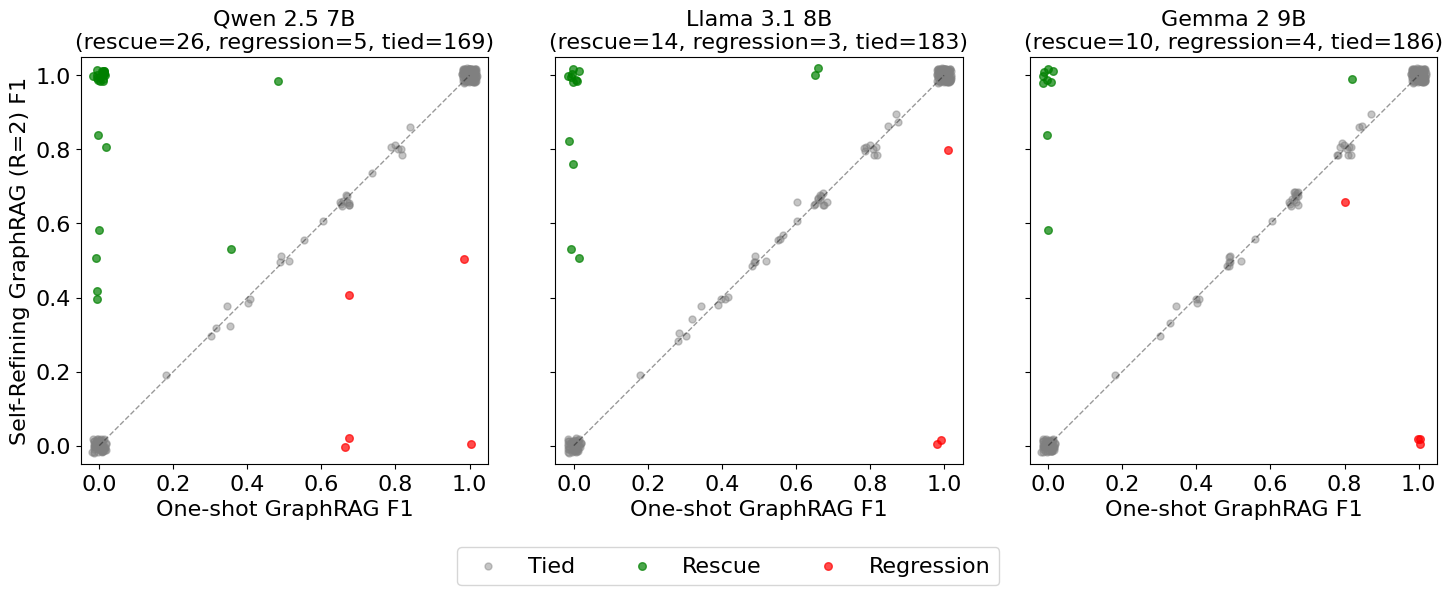

In [43]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharex=True, sharey=True)

# Collect per-backbone counts for caption/text, not the legend
for ax, (bk_name, bk) in zip(axes, data.items()):
    oneshot_by_q  = {r["question"]: r["f1"] for r in bk["oneshot_rows_200"]}
    refining_by_q = {r["question"]: r["f1"] for r in bk["refining_rows_200"]}
    x = np.array([oneshot_by_q[q] for q in oneshot_by_q])
    y = np.array([refining_by_q[q] for q in oneshot_by_q])
    
    deltas = y - x
    rescue_mask     = deltas >  0.1
    regression_mask = deltas < -0.1
    tied_mask       = ~(rescue_mask | regression_mask)
    
    rng = np.random.default_rng(42)
    jx = rng.uniform(-0.02, 0.02, len(x))
    jy = rng.uniform(-0.02, 0.02, len(y))
    
    ax.scatter(x[tied_mask] + jx[tied_mask], y[tied_mask] + jy[tied_mask],
               c="gray", alpha=0.45, s=25, label="Tied")
    ax.scatter(x[rescue_mask] + jx[rescue_mask], y[rescue_mask] + jy[rescue_mask],
               c="green", alpha=0.7, s=30, label="Rescue")
    ax.scatter(x[regression_mask] + jx[regression_mask], y[regression_mask] + jy[regression_mask],
               c="red", alpha=0.7, s=30, label="Regression")
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1)
    ax.set_xlabel("One-shot GraphRAG F1", fontsize=16)
    
    # Put counts in the title instead of the legend
    ax.set_title(
        f"{bk_name}\n(rescue={rescue_mask.sum()}, "
        f"regression={regression_mask.sum()}, tied={tied_mask.sum()})",
        fontsize=16
    )
    
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=16)

axes[0].set_ylabel("Self-Refining GraphRAG (R=2) F1", fontsize=16)

# Shared legend below the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="lower center", ncol=3,
    bbox_to_anchor=(0.5, -0.02), fontsize=16, frameon=True
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)  # slightly more room for bigger legend text
plt.savefig("figures/f1_scatter.pdf", bbox_inches="tight")
plt.savefig("figures/f1_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

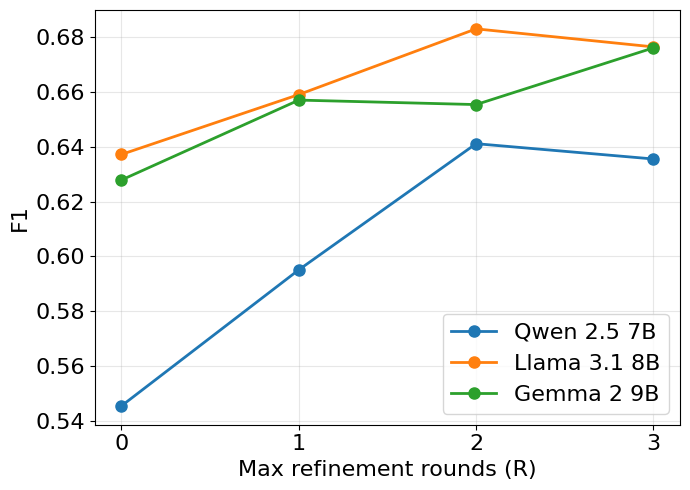

In [39]:
# F1 vs refinement depth. 
fig, ax = plt.subplots(figsize=(7, 5))

rounds = [0, 1, 2, 3]
for bk_name, bk in data.items():
    f1s = [
        np.mean([r["f1"] for r in bk["oneshot_rows_200"]]),
        np.mean([r["f1"] for r in bk["refining_r1_rows_200"]]),
        np.mean([r["f1"] for r in bk["refining_rows_200"]]),
        np.mean([r["f1"] for r in bk["refining_r3_rows_200"]]),
    ]
    ax.plot(rounds, f1s, marker="o", label=bk_name, linewidth=2, markersize=8)

ax.set_xlabel("Max refinement rounds (R)", fontsize=16)
ax.set_ylabel("F1", fontsize=16)
# ax.set_title("F1 vs refinement depth", fontsize=16)

ax.set_xticks(rounds)
ax.tick_params(axis="both", labelsize=16)

ax.legend(fontsize=16)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/f1_vs_rounds.pdf", bbox_inches="tight")
plt.savefig("figures/f1_vs_rounds.png", dpi=150, bbox_inches="tight")
plt.show()

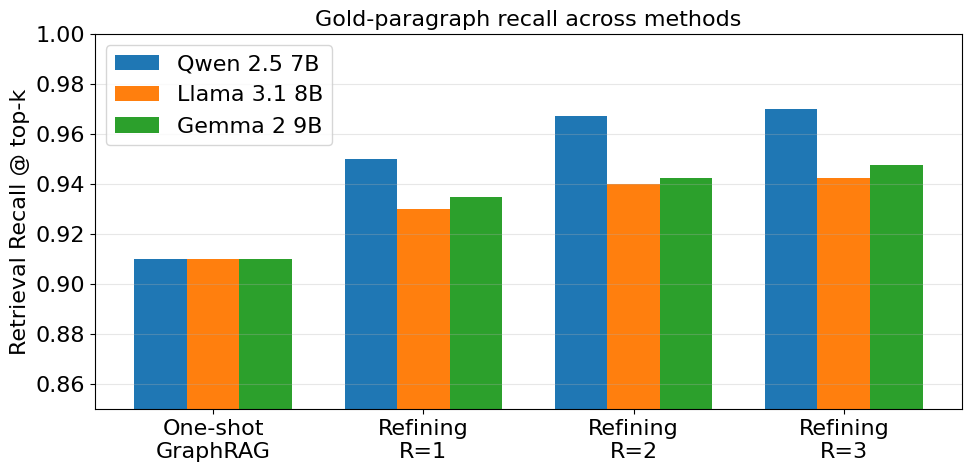

In [45]:
# Retrieval recall across refinement rounds
methods_order = ["One-shot\nGraphRAG", "Refining\nR=1", "Refining\nR=2", "Refining\nR=3"]
method_keys = ["oneshot_results_200", "refining_r1_results_200", 
               "refining_results_200", "refining_r3_results_200"]

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.25
x = np.arange(len(methods_order))

for i, (bk_name, bk) in enumerate(data.items()):
    recalls = [compute_recall(bk[k]) for k in method_keys]
    ax.bar(x + i*width, recalls, width, label=bk_name)

ax.set_xticks(x + width)
ax.set_xticklabels(methods_order)
ax.set_ylabel("Retrieval Recall @ top-k")
ax.set_title("Gold-paragraph recall across methods")
ax.set_ylim(0.85, 1.0)  # zoom in where the variation is
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("figures/recall_by_method.pdf", bbox_inches="tight")
plt.savefig("figures/recall_by_method.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
# Table for latex
import pickle
import pandas as pd
import numpy as np
from collections import Counter
import os

# --------- Load all three backbones ---------

BACKBONES = {
    "Qwen 2.5 7B": "qwen_results_checkpoint.pkl",
    "Llama 3.1 8B": "llama_results_checkpoint.pkl",
    "Gemma 2 9B": "gemma_results_checkpoint.pkl",
}

data = {}
for name, path in BACKBONES.items():
    with open(path, "rb") as f:
        data[name] = pickle.load(f)

# --------- Shared helpers ---------

def recall_fn(retrieved_titles, gold_titles):
    if not gold_titles:
        return 1.0
    return len(set(retrieved_titles) & set(gold_titles)) / len(gold_titles)

def mean_f1(rows, filter_fn=lambda r: True):
    xs = [r["f1"] for r in rows if filter_fn(r)]
    return np.mean(xs) if xs else float("nan")

def mean_em(rows):
    return np.mean([r["em"] for r in rows]) if rows else float("nan")

def compute_recall(results):
    return np.mean([recall_fn(r["retrieved_titles"], r["gold_titles"]) for r in results])

def count_wins(a_by_q, b_by_q, thresh=0.1):
    """Count how often B improves/ties/loses vs A, with mean delta."""
    imp = hurt = tied = 0
    deltas = []
    for q in a_by_q:
        delta = b_by_q[q]["f1"] - a_by_q[q]["f1"]
        deltas.append(delta)
        if delta > thresh: imp += 1
        elif delta < -thresh: hurt += 1
        else: tied += 1
    return imp, tied, hurt, float(np.mean(deltas))

def rescue_regression(base_by_q, method_by_q, thresh=0.5):
    base_wrong = [q for q in base_by_q if base_by_q[q]["f1"] < thresh]
    base_right = [q for q in base_by_q if base_by_q[q]["f1"] >= thresh]
    rescued = sum(1 for q in base_wrong if method_by_q[q]["f1"] >= thresh)
    broken = sum(1 for q in base_right if method_by_q[q]["f1"] < thresh)
    return rescued, len(base_wrong), broken, len(base_right)

os.makedirs("tables", exist_ok=True)


# ============================================================
# TABLE 1: MAIN RESULTS
# One row per (backbone, method). Shows the headline comparison.
# ============================================================

main_rows = []
for bk_name, bk in data.items():
    methods = [
        ("Vanilla RAG",       bk["vanilla_rows_200"],      bk["vanilla_results_200"]),
        ("One-shot GraphRAG", bk["oneshot_rows_200"],      bk["oneshot_results_200"]),
        ("Self-Refining (R=2)", bk["refining_rows_200"],   bk["refining_results_200"]),
    ]
    for m_name, rows, results in methods:
        main_rows.append({
            "Backbone": bk_name,
            "Method": m_name,
            "EM": mean_em(rows),
            "F1": mean_f1(rows),
            "Bridge F1":     mean_f1(rows, lambda r: r["type"] == "bridge"),
            "Comp. F1":      mean_f1(rows, lambda r: r["type"] == "comparison"),
            "Recall@3": compute_recall(results),
        })

main_table = pd.DataFrame(main_rows)
print("=== Table 1: Main Results ===")
print(main_table.to_string(index=False, float_format="%.3f"))

main_table.to_latex("tables/main_results.tex", index=False, float_format="%.3f",
    escape=True,
    caption=("Main results on HotpotQA distractor (n=200) across three open-source "
             "backbones. Self-Refining GraphRAG (R=2) consistently improves over "
             "both Vanilla RAG and One-shot GraphRAG on all backbones."),
    label="tab:main")


# ============================================================
# TABLE 2: ABLATIONS (depth of refinement + verifier-off)
# Shows that both design choices — iteration and verification — matter.
# ============================================================

ablation_rows = []
for bk_name, bk in data.items():
    variants = [
        ("One-shot GraphRAG (R=0)", bk["oneshot_rows_200"],       bk["oneshot_results_200"]),
        ("Refining R=1",            bk["refining_r1_rows_200"],   bk["refining_r1_results_200"]),
        ("Refining R=2",            bk["refining_rows_200"],      bk["refining_results_200"]),
        ("Refining R=3",            bk["refining_r3_rows_200"],   bk["refining_r3_results_200"]),
        ("Refining R=2, no verifier", bk["refining_noverif_rows_200"],
                                      bk["refining_noverif_results_200"]),
    ]
    for m_name, rows, results in variants:
        row = {
            "Backbone": bk_name,
            "Variant": m_name,
            "F1": mean_f1(rows),
            "Recall@3": compute_recall(results),
        }
        # Only refining variants have a round count
        if "refining" in m_name.lower() or "Refining" in m_name:
            rounds = [r.get("num_rounds", 0) for r in results]
            row["Avg Rounds"] = float(np.mean(rounds)) if rounds else 0.0
        else:
            row["Avg Rounds"] = 0.0
        ablation_rows.append(row)

ablation_table = pd.DataFrame(ablation_rows)
print("\n=== Table 2: Ablations ===")
print(ablation_table.to_string(index=False, float_format="%.3f"))

ablation_table.to_latex("tables/ablations.tex", index=False, float_format="%.3f",
    escape=True,
    caption=("Ablation study. Comparing refinement depth (R=1, 2, 3) and "
             "the effect of removing verifier-based early stopping ('no verifier', "
             "which forces max rounds on every question). R=2 with the verifier "
             "is the best tradeoff between quality and compute."),
    label="tab:ablations")


# ============================================================
# TABLE 3: RESCUE / REGRESSION ANALYSIS
# Answers: "When does the method help, and when does it hurt?"
# Computed vs One-shot GraphRAG (the relevant baseline for the refinement loop).
# ============================================================

rr_rows = []
for bk_name, bk in data.items():
    oneshot_by_q  = {r["question"]: r for r in bk["oneshot_rows_200"]}
    refining_by_q = {r["question"]: r for r in bk["refining_rows_200"]}
    
    imp, tied, hurt, mean_d = count_wins(oneshot_by_q, refining_by_q, thresh=0.1)
    rescued, n_wrong, broken, n_right = rescue_regression(oneshot_by_q, refining_by_q)
    
    rr_rows.append({
        "Backbone": bk_name,
        "Improved": imp,
        "Tied": tied,
        "Hurt": hurt,
        "Mean ΔF1": f"{mean_d:+.3f}",
        "Rescue rate":    f"{rescued}/{n_wrong} ({rescued/n_wrong:.1%})" if n_wrong else "—",
        "Regression rate": f"{broken}/{n_right} ({broken/n_right:.1%})" if n_right else "—",
    })

rr_table = pd.DataFrame(rr_rows)
print("\n=== Table 3: Rescue / Regression ===")
print(rr_table.to_string(index=False))

rr_table.to_latex("tables/rescue_regression.tex", index=False, escape=True,
    caption=("Per-question analysis of Self-Refining GraphRAG (R=2) vs One-shot "
             "GraphRAG. Rescue rate = fraction of baseline failures (F1 < 0.5) "
             "that the method corrects. Regression rate = fraction of baseline "
             "successes (F1 $\\geq$ 0.5) that the method breaks."),
    label="tab:rescue")


# ============================================================
# TABLE 4: QUALITATIVE EXAMPLES
# Three rescues + three regressions from the primary backbone (Qwen).
# One concrete table grounding the numerical story.
# ============================================================

def pretty(q, maxlen=70):
    return q if len(q) <= maxlen else q[:maxlen-3] + "..."

primary = data["Qwen 2.5 7B"]
vanilla_by_q  = {r["question"]: r for r in primary["vanilla_rows_200"]}
oneshot_by_q  = {r["question"]: r for r in primary["oneshot_rows_200"]}
refining_by_q = {r["question"]: r for r in primary["refining_rows_200"]}

successes, regressions = [], []
for q_text in vanilla_by_q:
    v, o, r = vanilla_by_q[q_text]["f1"], oneshot_by_q[q_text]["f1"], refining_by_q[q_text]["f1"]
    if v < 0.3 and o < 0.3 and r > 0.7:
        successes.append({
            "Question": pretty(q_text),
            "Gold": refining_by_q[q_text]["gold_answer"],
            "OneShot F1": f"{o:.2f}",
            "Refining F1": f"{r:.2f}",
            "Case": "Rescue",
        })
    elif o > 0.7 and r < 0.3:
        regressions.append({
            "Question": pretty(q_text),
            "Gold": refining_by_q[q_text]["gold_answer"],
            "OneShot F1": f"{o:.2f}",
            "Refining F1": f"{r:.2f}",
            "Case": "Regression",
        })

qual_table = pd.DataFrame(successes[:3] + regressions[:3])
print("\n=== Table 4: Qualitative Examples (Qwen) ===")
print(qual_table.to_string(index=False))

qual_table.to_latex("tables/qualitative.tex", index=False, escape=True,
    column_format="p{7cm}lccl",
    caption=("Representative cases from the Qwen 2.5 7B backbone. Rescue cases "
             "show questions where Self-Refining recovers from baseline failure; "
             "regression cases illustrate the primary failure mode of iterative "
             "refinement (distractor-induced answer flipping on comparison questions)."),
    label="tab:qualitative")


print("\nFour LaTeX files written to tables/")

=== Table 1: Main Results ===
    Backbone              Method    EM    F1  Bridge F1  Comp. F1  Recall@3
 Qwen 2.5 7B         Vanilla RAG 0.445 0.543      0.590     0.495     0.910
 Qwen 2.5 7B   One-shot GraphRAG 0.445 0.546      0.584     0.507     0.910
 Qwen 2.5 7B Self-Refining (R=2) 0.530 0.641      0.713     0.569     0.968
Llama 3.1 8B         Vanilla RAG 0.525 0.652      0.585     0.718     0.910
Llama 3.1 8B   One-shot GraphRAG 0.505 0.637      0.570     0.705     0.910
Llama 3.1 8B Self-Refining (R=2) 0.535 0.683      0.626     0.740     0.940
  Gemma 2 9B         Vanilla RAG 0.530 0.669      0.650     0.688     0.910
  Gemma 2 9B   One-shot GraphRAG 0.485 0.628      0.595     0.661     0.910
  Gemma 2 9B Self-Refining (R=2) 0.510 0.655      0.641     0.670     0.943

=== Table 2: Ablations ===
    Backbone                   Variant    F1  Recall@3  Avg Rounds
 Qwen 2.5 7B   One-shot GraphRAG (R=0) 0.546     0.910       0.000
 Qwen 2.5 7B              Refining R=1 0.595    